In [1]:
from dotenv import load_dotenv


load_dotenv()

True

- web search를 할 수 있는 API 키가 필요하다

#### 기존 코드 불러오기

In [2]:
# 생성된 벡터스토어에 접근 -> 클래스만 바로 써야 함
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='./income_tax_collection' 
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  

In [3]:
# state 생성

from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str  

    # 웹 서치와 벡터스토어의 문서 구조가 다르기 때문에 List로 선언 
    context:list # vector store 대상으로 검색을 했는데, 여기에서는 추가적으로 web search로 얻은 자료가 이 context에 들어간다
    answer: str


graph_builder = StateGraph(AgentState)  # 빌더 생성

In [4]:
# retrieve
def retrieve(state:AgentState):
    query = state['query']  
    docs = retriever.invoke(query)  
    return {'context' : docs}    

In [5]:
# llm과 prompt 분리 
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini')  # 가격을 위해서 mini로 대체

In [6]:
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser


generate_prompt = hub.pull("rlm/rag-prompt") 

# generate
def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context':context})
    return {'answer' : response} 

In [7]:
from langchain_classic import hub
from typing import Literal


doc_relevance_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']: 
    query = state['query']
    context = state['context']
    print(f'context == {context}') 
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents':context})  
    print(f'doc relevance response == {response}') 

    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'

#### 새로운 노드 생성

In [8]:
# rewrite

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 웹 검색에 용이하게 사용자의 질문 수정 -> 사전을 없애고, f-string 도 삭제해도 됨. 
rewrite_template = PromptTemplate.from_template("""
    사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 수정해주세요
    질문 : {query}
    """
)

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_template | llm | StrOutputParser()  
    response = rewrite_chain.invoke({'query': query}) 
    
    print(f'rewrite question == {response}')  # 로그
    return {'query': response}


In [9]:
from langchain_tavily import TavilySearch
# from langchain_community.tools import TavilySearch   # cannot import 에러

tavily_search_tool = TavilySearch(
    max_results=3, 
    include_answer=True,
    include_raw_content=True,
    include_images=True,
    search_depth="advanced",
    
)

# tavily_search_tool.invoke({"query": "What happened at the last wimbledon"})

def web_search(state: AgentState):
    query = state['query']
    results = tavily_search_tool.invoke(query)  # List 형태 반환
    print(f'web_search question == {results}')  # 로그
    return {'context' : results}   # results가 List 형식


- vector store 과의 차이점? -> 구조가 다르다
    - vector store : 'metadata', 'page_content' 키
    - tavily : 'url', 'content' 키
- AgentState 는 Document 형식이 아닌 List로 선언 (문서 구조가 다르기 때문)

- rewrite를 활성화할 경우

In [10]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
# graph_builder.add_node('check_doc_relevance', check_doc_relevance)  # 노드에 들어가면 안됨 -> 앞 강의 코드 참고
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [11]:
# 엣지 추가

from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant' : 'generate',
        'irrelevant' : 'rewrite'
    }

)


graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

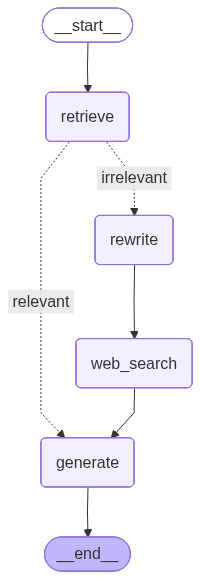

In [12]:
from IPython.display import Image, display

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))  

#### initial_state

In [13]:
initial_state = {'query' : '연봉 5천만원 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state) # score == 1

context == [Document(id='88ace334-edae-4d17-b6ba-850b2c9b99a5', metadata={'source': './docs/income_tax.txt'}, page_content='② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>\n  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. \n[개정 2014. 1. 1.]\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제2절 세액의 계산 <개정 2009. 12. 31.>\n제1관 세율 <개정 2009. 12. 31.>\n제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n종합소득\n┌───────────────┐\n│ 과세표

{'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='88ace334-edae-4d17-b6ba-850b2c9b99a5', metadata={'source': './docs/income_tax.txt'}, page_content='② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>\n  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. \n[개정 2014. 1. 1.]\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제2절 세액의 계산 <개정 2009. 12. 31.>\n제1관 세율 <개정 2009. 12. 31.>\n제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 1

In [14]:
dummy_state = {'query' : '선유도역 맛집은?'}  # 엉뚱한 질문 넣어보기
graph.invoke(dummy_state)
# score == 0
# 답변을 웹 서치를 통해서 나옴

# query': '"선유도역 맛집 추천"' => 질문 수정한 것을 볼 수 있음

context == [Document(id='9687cef7-b202-4f20-a7c9-e0686d20eddf', metadata={'source': './docs/income_tax.txt'}, page_content='삭제<2020. 8. 18.>\n\n\n삭제<2014. 1. 1.>\n\n\n삭제<2014. 1. 1.>\n\n\n삭제<2014. 1. 1.>\n\n\n제104조3)에 따른 비사업용 토지\n\n\n| 양도소득 과세표준  | 세율               |\n|--------------------|--------------------|\n| 1,400만원 이하    | 16% 센트          |\n| 1,400만원 초과    | 24만원 초과(1,400만원 초과액 × 25패센트) |\n| 5,000만원 이하    | 5,000만원 초과(1,124만원 + (5,000만원 초과액 × 34패센트)) |\n| 8,800만원 이하    | 8,800만원 초과(2,416만원 + (8,800만원 초과액 × 45패센트)) |\n| 1억5,000만원 초과 | 5,206만원 초과(1억5,000만원 초과액 × 48패센트) |\n| 3억원 이하        | 1억2,406만원(3억원 초과액 × 50패센트) |\n| 5억원 이하        | 2억2,406만원(5억원 초과액 × 52패센트) |\n| 10억원 이하       | 4억8,406만원(10억원 초과액 × 55패센트) |\n| 10억원 초과       |                    |\n법제처                                      국가법령정보센터\n소득세법\n\n제94조제1항제4호 및 규칙에 따른 자산 중 제104조의3에 따른 비사업용 토지의 보유 현황을 고려하여 대통형으로 정하는 자산\n\n| 유형                         | 세율                |\n|------------------------------|-------------

KeyboardInterrupt: 

- 사용자의 질문을 수정하는 rewrite 과정이 필요한지?
    - 공손한 표현을 쓰면 더 잘 나온다는 말도 있지만, 크게 의미 X

In [ ]:
# rewrite 노드를 제거하고, 엣지 연결 수정

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
# graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('web_search', web_search)

In [ ]:
# 엣지 추가
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant' : 'generate',
        'irrelevant' : 'web_search'  # rewrite 가 아니라 web_search로 바로 가도록
    }

)

# graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

In [ ]:
from IPython.display import Image, display

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))  

In [ ]:
dummy_state = {'query' : '선유도역 맛집은?'}  # 엉뚱한 질문 넣어보기
graph.invoke(dummy_state)
# score == 0
# 답변을 웹 서치를 통해서 나옴

# query': '"선유도역 맛집 추천"' => 질문 수정한 것을 볼 수 있음